<a href="https://colab.research.google.com/github/ajrotech/NCAI_Internship-/blob/main/Task_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [44]:
import pandas as pd

df = pd.read_csv("/content/Titanic_train.csv")

print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [45]:
df = pd.read_csv('/content/Titanic_test.csv')

In [46]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [47]:
df.shape

(418, 11)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [49]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [50]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**Handling missing data**

In [51]:
df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


**Data Cleaning**

Remove unnecessary columns

Passenger ID does not help prediction:

In [52]:
df.drop(
    ['PassengerId','Name','Ticket','Cabin'],
    axis=1,
    inplace=True
)

In [53]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [54]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [55]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(
    df['Sex']
)

In [56]:
df['Embarked'] = encoder.fit_transform(
    df['Embarked']
)

In [61]:
import pandas as pd

df = pd.read_csv("/content/Titanic_train.csv")

print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


**Separate Features and Target**

In [62]:
y = df['Survived']

In [58]:
print(df.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [63]:
X = df.drop(
    'Survived',
    axis=1
)

In [64]:
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Spilit Dataset**

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Drop irrelevant columns from both X_train and X_test
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')

# Impute missing 'Age' values with the median from X_train
median_age_train = X_train['Age'].median()
X_train['Age'] = X_train['Age'].fillna(median_age_train)
X_test['Age'] = X_test['Age'].fillna(median_age_train)

# Impute missing 'Fare' values with the median from X_train
median_fare_train = X_train['Fare'].median()
X_train['Fare'] = X_train['Fare'].fillna(median_fare_train)
X_test['Fare'] = X_test['Fare'].fillna(median_fare_train)

# Encode categorical features 'Sex' and 'Embarked'
# Sex
encoder_sex = LabelEncoder()
X_train['Sex'] = encoder_sex.fit_transform(X_train['Sex'])
X_test['Sex'] = encoder_sex.transform(X_test['Sex'])

# Embarked - first impute missing, then encode
mode_embarked_train = X_train['Embarked'].mode()[0]
X_train['Embarked'] = X_train['Embarked'].fillna(mode_embarked_train)
X_test['Embarked'] = X_test['Embarked'].fillna(mode_embarked_train)

encoder_embarked = LabelEncoder()
X_train['Embarked'] = encoder_embarked.fit_transform(X_train['Embarked'])
X_test['Embarked'] = encoder_embarked.transform(X_test['Embarked'])

# Initialize and apply StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [68]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

In [69]:
dt = DecisionTreeClassifier(
    random_state=42
)


dt.fit(
    X_train,
    y_train
)


dt_pred = dt.predict(
    X_test
)

In [70]:
rf = RandomForestClassifier(
    random_state=42
)


rf.fit(
    X_train,
    y_train
)


rf_pred = rf.predict(
    X_test
)

In [71]:
knn = KNeighborsClassifier()


knn.fit(
    X_train,
    y_train
)


knn_pred = knn.predict(
    X_test
)

In [72]:
def evaluate_model(name, y_test, prediction):

    print(name)

    print(
        "Accuracy:",
        accuracy_score(y_test,prediction)
    )

    print(
        "Precision:",
        precision_score(y_test,prediction)
    )

    print(
        "Recall:",
        recall_score(y_test,prediction)
    )

    print(
        "F1 Score:",
        f1_score(y_test,prediction)
    )

    print("----------------")

In [73]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)


evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)


evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)


evaluate_model(
    "KNN",
    y_test,
    knn_pred
)

Logistic Regression
Accuracy: 0.8044692737430168
Precision: 0.782608695652174
Recall: 0.7297297297297297
F1 Score: 0.7552447552447552
----------------
Decision Tree
Accuracy: 0.7821229050279329
Precision: 0.7215189873417721
Recall: 0.7702702702702703
F1 Score: 0.7450980392156863
----------------
Random Forest
Accuracy: 0.8212290502793296
Precision: 0.8088235294117647
Recall: 0.7432432432432432
F1 Score: 0.7746478873239436
----------------
KNN
Accuracy: 0.8044692737430168
Precision: 0.782608695652174
Recall: 0.7297297297297297
F1 Score: 0.7552447552447552
----------------


In [74]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,knn_pred)
    ]
})


results

,Model,Accuracy
0,Logistic Regression,0.804469
1,Decision Tree,0.782123
2,Random Forest,0.821229
3,KNN,0.804469


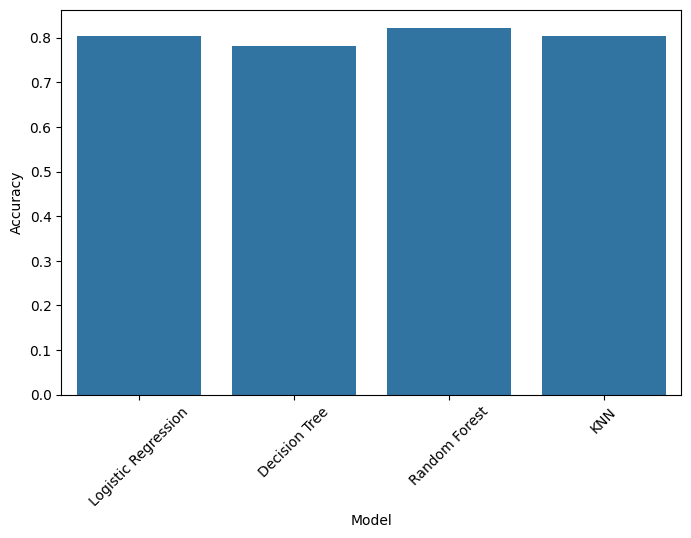

In [75]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=45)

plt.show()